# 1 — Veri Setini Yükleme ve Keşfetme

## 1.1. Kütüphane İmportları

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px
import nltk

## 1.2. Görsel Ayarları

In [15]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 1.3. Veriyi Yükleme

In [16]:
df = pd.read_excel('ds_salaries.xlsx')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## 1.4. İlk Keşif

In [17]:
print("Boyut:", df.shape)
print("\nSütunlar:", df.columns.tolist())
print("\nVeri tipleri:\n", df.dtypes)
print("\nEksik değerler:\n", df.isnull().sum())

Boyut: (3755, 11)

Sütunlar: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Veri tipleri:
 work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

Eksik değerler:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


# 2 — Tanımsal İstatistikler

## 2.1. Genel Özet

In [18]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [20]:
df.describe(include="object")

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


In [11]:
# Value Counts

categorical_cols = [
    'experience_level',
    'employment_type',
    'job_title',
    'salary_currency',
    'employee_residence',
    'company_location',
    'company_size',
    'remote_ratio',
    'work_year'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- experience_level ---
experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

--- employment_type ---
employment_type
FT    3718
PT      17
CT      10
FL      10
Name: count, dtype: int64

--- job_title ---
job_title
Data Engineer                          1040
Data Scientist                          840
Data Analyst                            612
Machine Learning Engineer               289
Analytics Engineer                      103
                                       ... 
Principal Machine Learning Engineer       1
Azure Data Engineer                       1
Manager Data Management                   1
Marketing Data Engineer                   1
Finance Data Analyst                      1
Name: count, Length: 93, dtype: int64

--- salary_currency ---
salary_currency
USD    3224
EUR     236
GBP     161
INR      60
CAD      25
AUD       9
SGD       6
BRL       6
PLN       5
CHF       4
HUF       3
DKK       3
JPY       3
TRY       3
THB       2
ILS 

In [12]:
df.groupby("job_title")["salary_in_usd"] \
  .agg(
      mean="mean",
      median="median",
      std="std",
      count="count"
  ) \
  .round(2) \
  .sort_values(by="mean", ascending=False)

,mean,median,std,count
job_title,,,,
Data Science Tech Lead,375000.00,375000.0,NaN,1
Cloud Data Architect,250000.00,250000.0,NaN,1
Data Lead,212500.00,212500.0,17677.67,2
Data Analytics Lead,211254.50,211254.5,273997.51,2
Principal Data Scientist,198171.12,164630.5,99306.05,8
...,...,...,...,...
Autonomous Vehicle Technician,26277.50,26277.5,27262.50,2
3D Computer Vision Researcher,21352.25,15000.0,20046.47,4
Staff Data Analyst,15000.00,15000.0,NaN,1


In [13]:
df.groupby(["job_title", "experience_level"])["salary_in_usd"]\
  .mean()\
  .sort_values(ascending=False)

job_title                           experience_level
Principal Data Scientist            EX                  416000.000000
Data Analytics Lead                 SE                  405000.000000
Data Science Tech Lead              SE                  375000.000000
Cloud Data Architect                SE                  250000.000000
Head of Data                        EX                  238183.333333
                                                            ...      
Machine Learning Software Engineer  EN                   10000.000000
Product Data Scientist              SE                    8000.000000
Autonomous Vehicle Technician       EN                    7000.000000
Power BI Developer                  EN                    5409.000000
3D Computer Vision Researcher       MI                    5409.000000
Name: salary_in_usd, Length: 192, dtype: float64

In [14]:
df.select_dtypes(include=np.number).corr()

,work_year,salary,salary_in_usd,remote_ratio
work_year,1.000000,-0.094724,0.228290,-0.236430
salary,-0.094724,1.000000,-0.023676,0.028731
salary_in_usd,0.228290,-0.023676,1.000000,-0.064171
remote_ratio,-0.236430,0.028731,-0.064171,1.000000


# 3 — Grafikler

## 3.1) ABD Doları Cinsinden Maaşlar

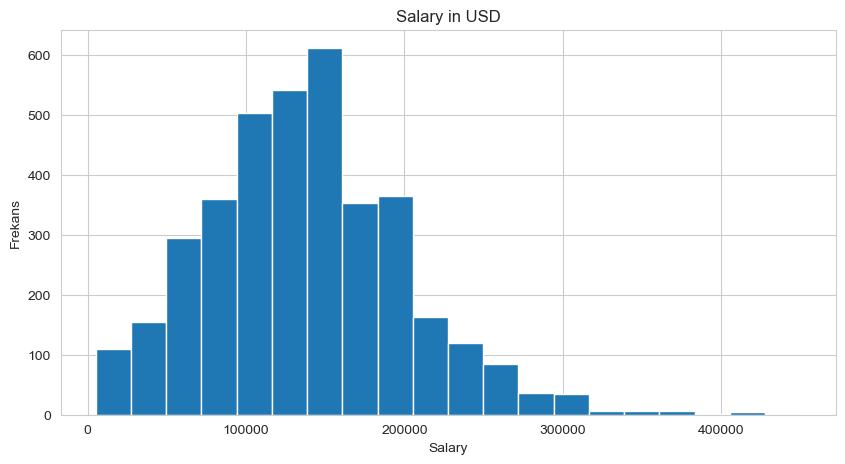

In [7]:
fig, ax = plt.subplots()
df["salary_in_usd"].hist(bins=20, ax=ax)
ax.set_title("Salary in USD")
ax.set_xlabel("Salary")
ax.set_ylabel("Frekans")
plt.show()

### Yorum
     
Grafik incelendiğinde, veri dağılımının sağ tarafa doğru uzanan bir kuyruğa sahip olduğu görülür. Bu durum, veri bilimindeki maaşların çoğunluğunun belirli bir ortalama düzeyde kümelendiğini, ancak az sayıda kişinin çok yüksek maaşlar aldığını gösterir. Dağılımın çarpıklık katsayısı (skewness) yaklaşık olarak $0.54$ olup, hafif-orta derecede sağa çarpık bir yapıyı doğrulamaktadır.
     
Ortalama maaş 137,570$ USD seviyesindedir. Sağ taraftaki yüksek maaşların (uzun kuyruğun) etkisiyle ortalama değer, medyan değerinden daha büyüktür ({Ortalama} > {Medyan}). Bu ilişki istatistiksel olarak sağa çarpık dağılımların tipik bir özelliğidir.

Tek Tepeli (Unimodal): Grafikte tek bir belirgin tepe noktası (mod) bulunmaktadır. Bu da maaşların belirli bir ana grup etrafında yoğunlaştığı anlamına gelir.

Histogramdaki çubukların (bin'lerin) frekansları incelendiğinde, en yüksek sütunların yaklaşık 94,000$ ile 161,000$ USD arasında yer aldığı görülür. Özellikle 138,500$ - 161,000$ aralığı veri setindeki en yüksek çalışan frekansına (mod bölgesine) sahiptir.

Medyan (Ortanca Değer): Verinin tam ortasındaki değer 135,000$ USD'dir. Yani veri setindeki çalışanların tam olarak %50'si bu değerden daha az, diğer %50'si ise bu değerden daha fazla kazanmaktadır.

## 3.2. Yıllara Göre Dağılım

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


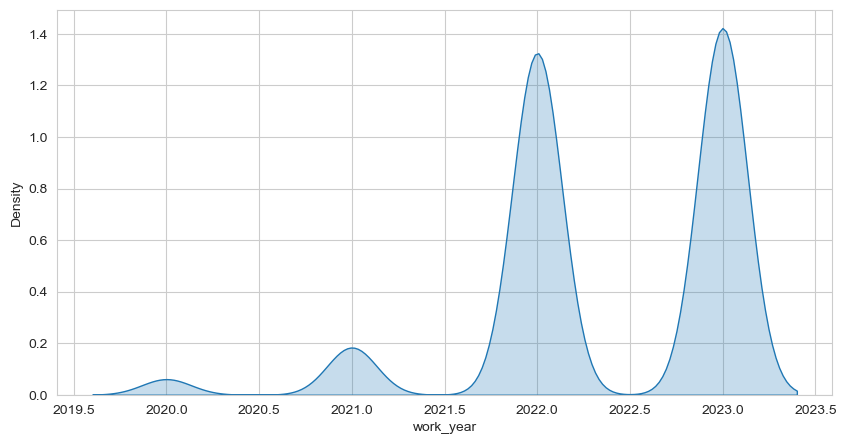

In [8]:
sns.kdeplot(df["work_year"], fill=True)
plt.show()

### Yorum:

Grafik, sol tarafta (2020-2021 civarı) oldukça düşük ve basık bir eğriyle başlarken, sağ tarafa (2022-2023 civarı) doğru dik ve çok yüksek zirveler (tepe noktaları) yapmaktadır. Bu durum, veri setindeki veri toplama veya istihdam hacminin zamanla katlanarak arttığını gösterir.

Grafiğin sol tarafındaki basıklık, bu yıllara ait verilerin toplam veri setinin yalnızca yaklaşık %8'ini oluşturmasından kaynaklanır (2020'de 76, 2021'de 230 veri).

Grafiğin zirve yaptığı ve alanın en geniş olduğu sağ taraf, verilerin ezici çoğunluğunun bu döneme ait olduğunu gösterir. Verilerin yaklaşık %92'si (2022'de 1664, 2023'te 1785 veri) bu iki yıla yığılmıştır.

## 3.3. ABD Doları Cinsinden Maaşlar

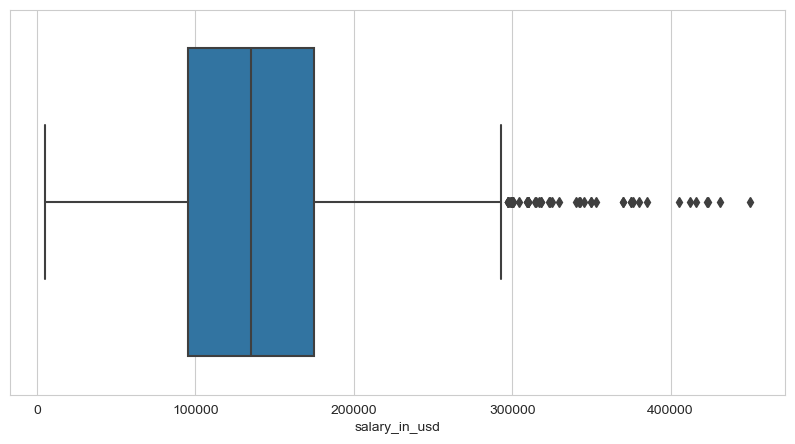

In [9]:
sns.boxplot(x=df["salary_in_usd"])
plt.title("")
plt.show()

### Yorum:

Kutunun ortasındaki çizgi 135,000 USD seviyesindedir. Veri bilimcilerin tam olarak yarısı bu değerden daha az, diğer yarısı ise daha fazla kazanmaktadır.

Kutunun sol kenarı (%25 birinci çeyreklik) 95,000 USD, sağ kenarı ise (%75 üçüncü çeyreklik) 175,000 USD'dir. Sektördeki çalışanların en standart $\%50$'lik dilimi bu iki değer arasında maaş almaktadır (Kutu genişliği / IQR = 80,000 USD).

Soldaki bıyık veri setindeki en düşük maaşlara (yaklaşık 5,132) kadar uzanır. Sağdaki bıyık ise normal dağılım sınırının üst limiti olan yaklaşık 295,000 USD seviyesinde sonlanır.

Sağ bıyığın bitiminden sonra başlayıp 450,000 USD'ye kadar uzanan tekil noktalar, sektör ortalamasının çok üzerinde kazanan aykırı değerleri (outliers) gösterir. Bu durum, maaş dağılımının sağa çarpık (yüksek değerlere doğru uzayan) bir yapıda olduğunu doğrulamaktadır.

## 3.4. Yıllara Göre Ortalama Maaş (USD)

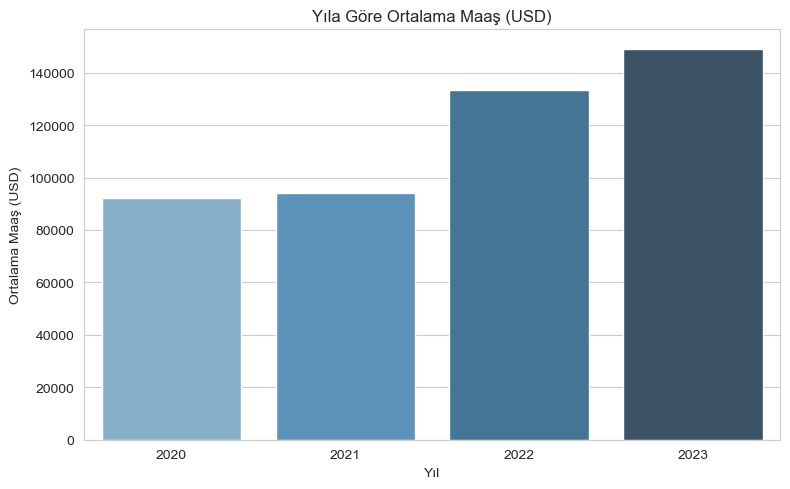

In [10]:
yearly_salary = df.groupby("work_year")["salary_in_usd"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=yearly_salary, x="work_year", y="salary_in_usd", palette="Blues_d")
plt.title("Yıla Göre Ortalama Maaş (USD)")
plt.ylabel("Ortalama Maaş (USD)")
plt.xlabel("Yıl")
plt.tight_layout()
plt.show()

### Yorum

Grafik, 2020 yılından 2023 yılına kadar veri bilimi rollerindeki ortalama maaşların kesintisiz bir şekilde yükseldiğini net olarak ortaya koymaktadır.

Ortalama maaşlar 2020'de yaklaşık 92,300 USD iken 2021'de küçük bir artışla 94,100 USD seviyesine gelmiştir. Bu dönemde artış hızı oldukça düşüktür.

Grafikteki en dikkat çekici değişim bu iki yıl arasında gerçekleşmiştir. Ortalama maaşlar bir yılda yaklaşık %41.7 gibi çok ciddi bir oranla artarak 133,300 USD seviyesine fırlamıştır. Bu sert yükseliş, pandemi sonrası veri odaklı rollere olan talebin patlamasını veya veri setine yüksek maaşlı kıdemli (Senior/Expert) pozisyonların daha fazla dahil olmasını yansıtıyor olabilir.

Artış trendi devam etmiş ve 2023 yılında ortalama maaşlar 149,000 USD seviyesine ulaşarak grafikteki en yüksek sütunu (zirveyi) oluşturmuştur.

## 3.5. Deneyim Düzeyine Göre Ortalama Maaş

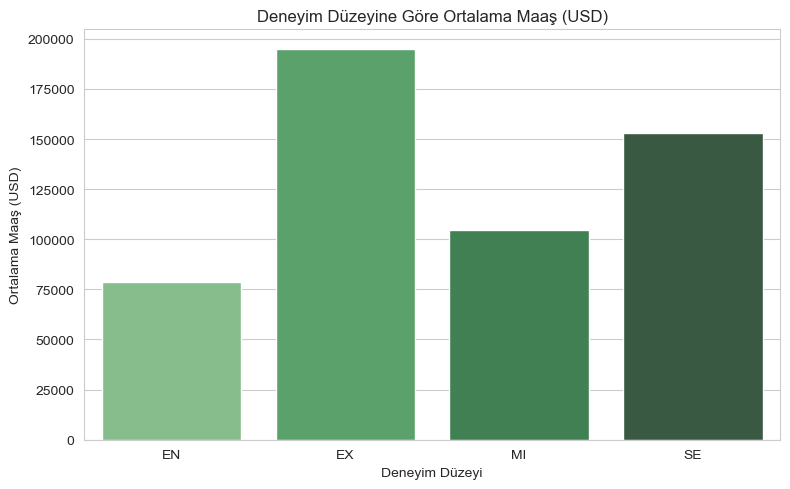

In [11]:
exp_salary = df.groupby("experience_level")["salary_in_usd"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=exp_salary, x="experience_level", y="salary_in_usd", palette="Greens_d")
plt.title("Deneyim Düzeyine Göre Ortalama Maaş (USD)")
plt.ylabel("Ortalama Maaş (USD)")
plt.xlabel("Deneyim Düzeyi")
plt.tight_layout()
plt.show()

### Yorum

Deneyim düzeyi ile maaş arasında çok net ve doğru orantılı bir ilişki vardır. Kariyer basamakları tırmanıldıkça ortalama kazanç düzenli olarak yükselmektedir. Sektöre yeni adım atanların ortalama maaşı yaklaşık 78,546 USD ile grafikteki en düşük sütunu oluşturur.

Birkaç yıllık deneyimle birlikte ortalama maaş belirgin bir sıçrama yaparak yaklaşık 104,526 USD seviyesine ulaşır. Uzmanlaşan ve kıdem kazanan çalışanların ortalama maaşı 153,051 USD seviyesine çıkarak güçlü bir finansal getiri sağlar.

Direktör, CTO veya departman lideri gibi üst düzey rollerin ortalama kazancı yaklaşık 194,931 USD ile zirve noktayı (en yüksek sütunu) temsil eder.

## 3.6. Grafik 3: En Yaygın 10 İş Unvanı

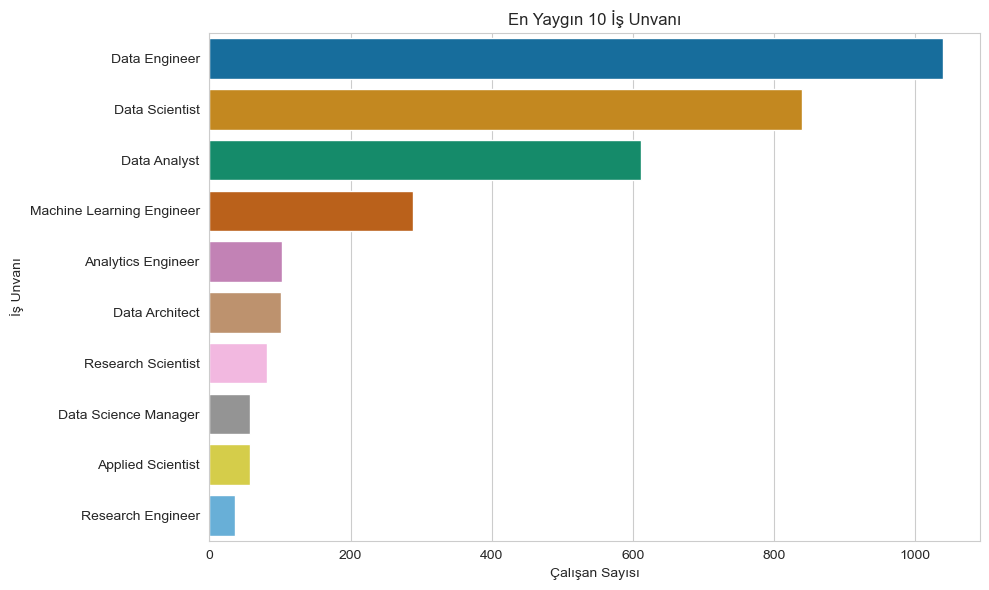

In [12]:
top_jobs = df["job_title"].value_counts().nlargest(10).reset_index()
top_jobs.columns = ["job_title", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_jobs, y="job_title", x="count", palette="colorblind")
plt.title("En Yaygın 10 İş Unvanı")
plt.xlabel("Çalışan Sayısı")
plt.ylabel("İş Unvanı")
plt.tight_layout()
plt.show()

### Yorum

Grafiğin en tepesindeki ilk üç unvan, veri dünyasının ana omurgasını oluşturur ve toplam ilanların/çalışanların ezici bir çoğunluğunu kapsar. 

1,040 çalışanla açık ara en yaygın pozisyondur. Sektörde veri altyapısına ve boru hatlarına (pipeline) olan ihtiyacın büyüklüğünü gösterir. 840 çalışanla ikinci sırada yer alır ve popülerliğini güçlü bir şekilde korumaktadır. 612 çalışanla üçüncü sırada gelerek veriyi yorumlama ve raporlama rollerinin yaygınlığını doğrular.

## 3.7. Zaman Serisi: Yıllara Göre Ortalama Maaş Değişimi

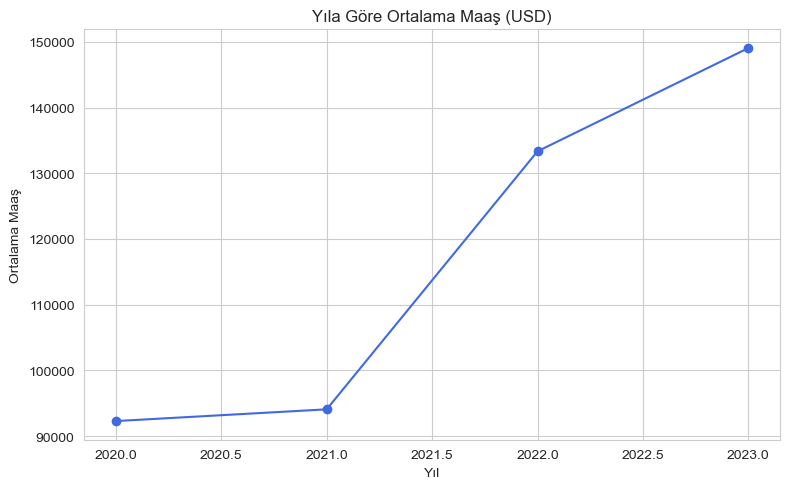

In [13]:
# Ortalama maaşları yıl bazında grupla
avg_salary = df.groupby('work_year')['salary_in_usd'].mean()

# Zaman serisi çizimi
plt.figure(figsize=(8, 5))
plt.plot(avg_salary.index, avg_salary.values, marker='o', linestyle='-', color='royalblue')
plt.title('Yıla Göre Ortalama Maaş (USD)')
plt.xlabel('Yıl')
plt.ylabel('Ortalama Maaş')
plt.grid(True)
plt.tight_layout()
plt.show()

### Yorum

Grafik sol alttan sağ üste doğru sürekli yükselen bir hat çizmektedir. Bu, 2020 ile 2023 yılları arasında veri dünyasındaki ortalama maaşların kesintisiz bir büyüme trendinde olduğunu doğrular.

2020 - 2021 Arası: Çizgi neredeyse düz (yatay) bir eğime sahiptir. Maaşlar yaklaşık $\$92,300$ USD'den $\$94,100$ USD seviyesine çok yavaş bir hızla yükselmiştir.

2021 - 2022 Arası: Grafikteki çizgi dikleşerek sert bir yukarı yönlü ivme kazanmıştır. Maaşların yaklaşık $\$133,300$ USD seviyesine fırladığı bu dönem, pazarın en agresif büyüme gösterdiği zaman dilimidir.

2022 - 2023 Arası: Yükseliş ivmesi dikliğini koruyarak devam etmiş ve ortalama kazançlar $\$149,000$ USD ile tepe noktasına ulaşmıştır.

# 4) Bulgular

### Yorum

1. Veri Bilimi Sektöründe Küresel Maaş Artışı ve Trendler

Veri setindeki zaman serisi analizleri, veri odaklı rollere olan talebin ve finansal getirilerin son yıllarda kesintisiz ve agresif bir şekilde büyüdüğünü göstermektedir. 2020 yılında 92,302 USD olan küresel ortalama maaş, pandeminin ardından özellikle 2022 yılında çok sert bir sıçrama yaşayarak 133,338 USD seviyesine ulaşmıştır. Bu yukarı yönlü ivme 2023 yılında da devam etmiş ve ortalama yıllık maaş 149,045 USD ile zirve noktasına ulaşmıştır. Bu durum, pazarın genel olarak genişlediğini ve sektörel değerinin arttığını kanıtlamaktadır.


2. Deneyim Düzeyinin Maaş Üzerindeki Doğrudan Çarpan Etkisi

Kariyer basamakları ile finansal kazanç arasında doğrusal ve güçlü bir korelasyon bulunmaktadır. Sektöre yeni adım atan giriş seviyesi (EN) çalışanlar yıllık ortalama 78,546 USD kazanırken, orta düzey (MI) deneyimle birlikte bu tutar 104,525 USD seviyesine çıkmaktadır. Kıdemli uzmanların (SE) ortalama kazancı 153,051 USD bandına ulaşırken, yönetim ve direktörlük seviyesindeki (EX) liderler 194,930 USD ortalama ile en yüksek gelir grubunu oluşturmaktadır. Veriler, sektörde deneyim biriktirmenin çok ciddi bir finansal çarpan etkisi yarattığını ortaya koymaktadır.

3. İstihdamın Omurgası: Veri Mühendisliği ve Modelleme Rolleri

Piyasadaki iş unvanlarının dağılımı incelendiğinde, istihdam hacminin büyük bir kısmının belirli ana rollerde kümelendiği görülmektedir. Veri setinde "Data Engineer" (Veri Mühendisi) 1.040 çalışan ile açık ara en çok istihdam edilen pozisyon durumundadır; bu da şirketlerin öncelikle veri altyapısı ve boru hatlarına yatırım yaptığını göstermektedir. Bunu sırasıyla "Data Scientist" (840 çalışan) ve "Data Analyst" (612 çalışan) takip etmektedir. Yapay zeka uygulamalarının yaygınlaşmasıyla "Machine Learning Engineer" (289 çalışan) unvanı da pazarda dördüncü büyük güç olarak konumlanmıştır. Sektörün istihdam yükünü büyük oranda bu roller sırtlamaktadır.

# 5) Kaynakça

https://github.com/ogzhnylmz1/Data_Scientist_Salaries


https://ogzhnylmz1.github.io/Data_Scientist_Salaries/